## Import des librairies

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [55]:
# Chargement du dataset
df = pd.read_csv("beer_reviews.csv")



## Analyse descriptive rapide

In [56]:
#Aperçu rapide des données
#mon review_time affiche des dates/heures des tests
df.head()


,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,10325,Vecchio Birraio,1234817823,1.5,2.0,2.5,stcules,Hefeweizen,1.5,1.5,Sausa Weizen,5.0,47986
1,10325,Vecchio Birraio,1235915097,3.0,2.5,3.0,stcules,English Strong Ale,3.0,3.0,Red Moon,6.2,48213
2,10325,Vecchio Birraio,1235916604,3.0,2.5,3.0,stcules,Foreign / Export Stout,3.0,3.0,Black Horse Black Beer,6.5,48215
3,10325,Vecchio Birraio,1234725145,3.0,3.0,3.5,stcules,German Pilsener,2.5,3.0,Sausa Pils,5.0,47969
4,1075,Caldera Brewing Company,1293735206,4.0,4.5,4.0,johnmichaelsen,American Double / Imperial IPA,4.0,4.5,Cauldron DIPA,7.7,64883


In [57]:
df.info() #format de mes données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586614 entries, 0 to 1586613
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   brewery_id          1586614 non-null  int64  
 1   brewery_name        1586599 non-null  object 
 2   review_time         1586614 non-null  int64  
 3   review_overall      1586614 non-null  float64
 4   review_aroma        1586614 non-null  float64
 5   review_appearance   1586614 non-null  float64
 6   review_profilename  1586266 non-null  object 
 7   beer_style          1586614 non-null  object 
 8   review_palate       1586614 non-null  float64
 9   review_taste        1586614 non-null  float64
 10  beer_name           1586614 non-null  object 
 11  beer_abv            1518829 non-null  float64
 12  beer_beerid         1586614 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 157.4+ MB


*Contenu du dataset*

* 13 variables
* dont 6, variables quantitatives : review_overall, review_aroma, review_appearance, review_palate, review_taste, beer_abv
* dont 4, variables qualitatives : brewery_name, review_profilname, beer_style, beer_name
* dont 3, variables quantitatives "d'identité": ID brasserie, ID bière, date et heure d'enregistrement

*Identification des valeurs nulles*

In [58]:
#est ce que j'ai des valeurs nulles ?
print("identification des valeurs nulles...")
print(df.isnull().sum()) #somme des valeurs nulle du data_frame

identification des valeurs nulles...
brewery_id                0
brewery_name             15
review_time               0
review_overall            0
review_aroma              0
review_appearance         0
review_profilename      348
beer_style                0
review_palate             0
review_taste              0
beer_name                 0
beer_abv              67785
beer_beerid               0
dtype: int64


In [59]:
df = df.dropna(subset=['brewery_name', 'review_profilename', "beer_abv"])
print("...et suppression des valeurs nulles...OK")

...et suppression des valeurs nulles...OK


*Identification et suppression des des doublons*

In [60]:
print("identification des valeurs doublons dans profil_name et beer_name...")

df = df.drop_duplicates(subset= ['review_profilename','beer_name'], keep='first')

df.info()

print("Pourcentage de valeurs en doublons:", round((1586613 - 1496263)/ 1586613 * 100, 2),"%")

print("...et suppression des valeurs doublons...OK")

identification des valeurs doublons dans profil_name et beer_name...
<class 'pandas.core.frame.DataFrame'>
Index: 1496263 entries, 0 to 1586613
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   brewery_id          1496263 non-null  int64  
 1   brewery_name        1496263 non-null  object 
 2   review_time         1496263 non-null  int64  
 3   review_overall      1496263 non-null  float64
 4   review_aroma        1496263 non-null  float64
 5   review_appearance   1496263 non-null  float64
 6   review_profilename  1496263 non-null  object 
 7   beer_style          1496263 non-null  object 
 8   review_palate       1496263 non-null  float64
 9   review_taste        1496263 non-null  float64
 10  beer_name           1496263 non-null  object 
 11  beer_abv            1496263 non-null  float64
 12  beer_beerid         1496263 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 159.

## Principaux éléments du dataset - variables quantitatives
- Count (nombre)
- Moyenne (mean)
- Médiane (50%)
- Minimum (min)
- Maximum (max)
- Écart-type (std)
- Quartiles (25% et 75%)

In [61]:
df.describe().round(2)

,brewery_id,review_time,review_overall,review_aroma,review_appearance,review_palate,review_taste,beer_abv,beer_beerid
count,1496263.00,1.496263e+06,1496263.00,1496263.00,1496263.00,1496263.00,1496263.00,1496263.00,1496263.00
mean,3068.15,1.225593e+09,3.82,3.75,3.85,3.75,3.80,7.05,21434.49
std,5540.52,7.572180e+07,0.72,0.70,0.61,0.68,0.73,2.33,21798.31
min,1.00,8.843904e+08,0.00,1.00,0.00,1.00,1.00,0.01,5.00
25%,141.00,1.175915e+09,3.50,3.50,3.50,3.50,3.50,5.20,1655.00
50%,414.00,1.240608e+09,4.00,4.00,4.00,4.00,4.00,6.50,12895.00
75%,2250.00,1.289257e+09,4.50,4.00,4.00,4.00,4.50,8.50,39273.00
max,28003.00,1.326285e+09,5.00,5.00,5.00,5.00,5.00,57.70,77316.00


* En moyenne,
* Note générale : 3.82/5 (avec des valeurs à 0)
* Note arôme : 3.75/5
* Note apparence : 3.85/5 (avec des valeurs à 0)
* Note palais : 3.75/5
* Note goût : 3.80/5
* Ecart-type à la moyenne compris entre 0.61 et 0.73 --> en moyenne je suis écarté de 0.62 à 0.73 pts par rapport à la moyenne sur les variables overall / aroma / appearance / palate / taste
* 68% de mon échantillon est compris entre note générale de 3.82 +/- 0.72 pts
* Degré d'alcool moyen : 7.04° 
* 68% de mon échantillon est compris entre avec un degré d'alcool de 7.04 +/- 2.33° d'alcool


*Distribution des valeurs*

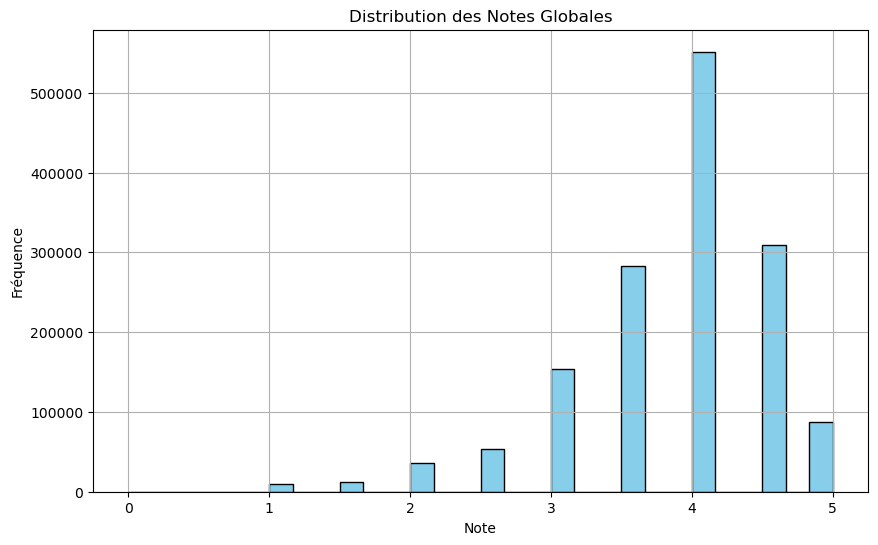

In [62]:
# Note globale
plt.figure(figsize=(10, 6))
df['review_overall'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution des Notes Globales')
plt.xlabel('Note')
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()

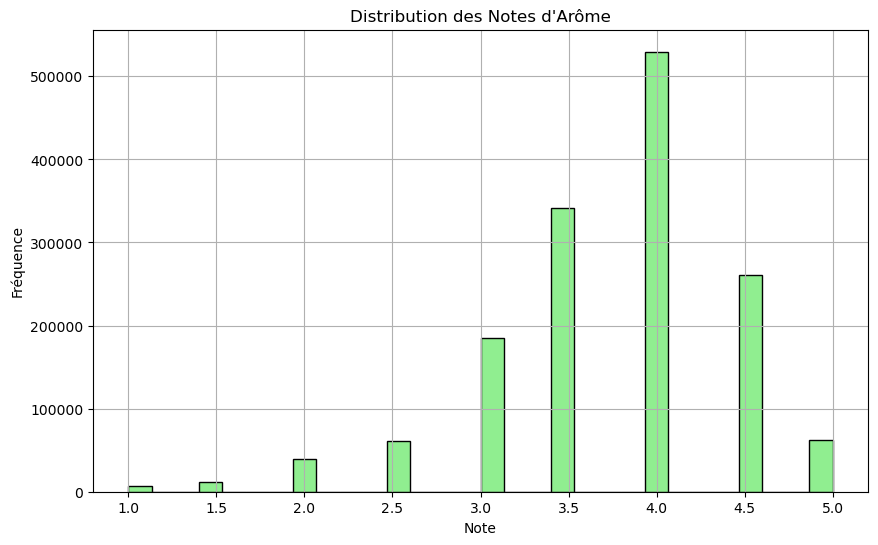

In [63]:
# Note d'arôme
plt.figure(figsize=(10, 6))
df['review_aroma'].hist(bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution des Notes d\'Arôme')
plt.xlabel('Note')
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()

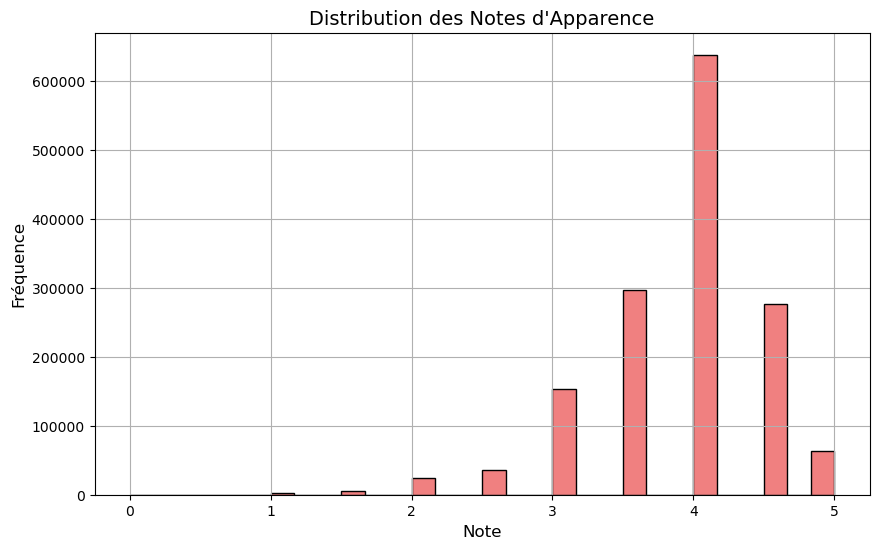

In [64]:
# Note d'apparence
plt.figure(figsize=(10, 6))
df['review_appearance'].hist(bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution des Notes d\'Apparence', fontsize=14)
plt.xlabel('Note', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.grid(True)
plt.show()

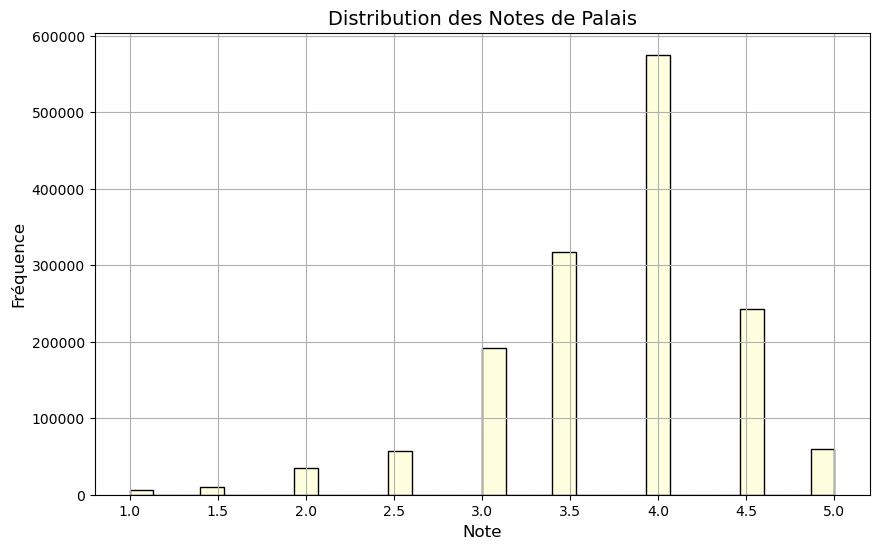

In [65]:
# Note de palais
plt.figure(figsize=(10, 6))
df['review_palate'].hist(bins=30, color='lightyellow', edgecolor='black')
plt.title('Distribution des Notes de Palais', fontsize=14)
plt.xlabel('Note', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.grid(True)
plt.show()


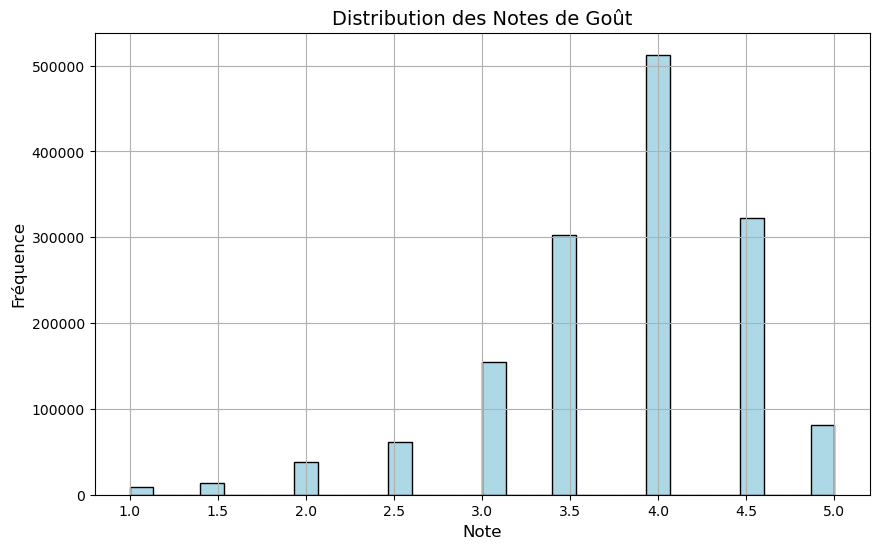

In [66]:
# Note de goût
plt.figure(figsize=(10, 6))
df['review_taste'].hist(bins=30, color='lightblue', edgecolor='black')
plt.title('Distribution des Notes de Goût', fontsize=14)
plt.xlabel('Note', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.grid(True)
plt.show()


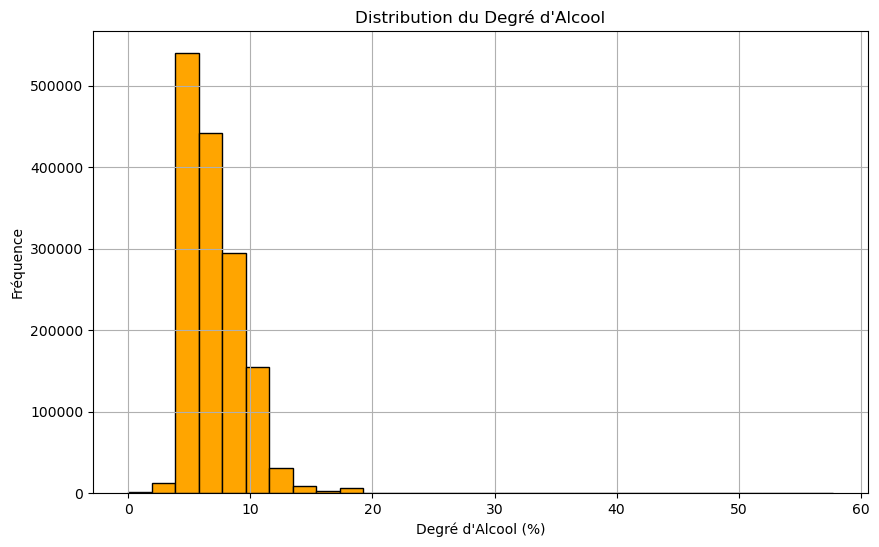

In [67]:
#degré d'alcool
plt.figure(figsize=(10, 6))
df['beer_abv'].hist(bins=30, color='orange', edgecolor='black')
plt.title('Distribution du Degré d\'Alcool')
plt.xlabel('Degré d\'Alcool (%)')
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()

# Principaux éléments du dataset - variables qualitatives



In [68]:
print('identification du nombre de brasseries testées...')
print(df['brewery_name'].value_counts()) #identifier les brasseries testées

print('...5 135 brasseries différentes testées')

identification du nombre de brasseries testées...
brewery_name
Boston Beer Company (Samuel Adams)                    38533
Dogfish Head Brewery                                  33339
Stone Brewing Co.                                     32525
Sierra Nevada Brewing Co.                             28237
Bell's Brewery, Inc.                                  24610
                                                      ...  
Giessener Brauhaus                                        1
Brasserie Henri Monier                                    1
Pivobezalkogolniy Zavod Severskovo Pischekombinata        1
Alt-Oberurseler Brauhaus                                  1
Brasserie De Lautène                                      1
Name: count, Length: 5135, dtype: int64
...5 135 brasseries différentes testées


In [69]:
print('identification du nombre de testeurs différents...')
print(df['review_profilename'].value_counts()) #identifier les testeurs uniques

print('...32 908 testeurs uniques')

identification du nombre de testeurs différents...
review_profilename
northyorksammy    5177
BuckeyeNation     4144
mikesgroove       4130
Thorpe429         3228
womencantsail     3115
                  ... 
chapcat              1
RudeDog              1
JMooLaH              1
adamrk               1
Scottnr88            1
Name: count, Length: 32908, dtype: int64
...32 908 testeurs uniques


In [70]:
print('identification du nombre de bières différentes...')
print(df['beer_beerid'].value_counts()) #identifier le nombre de bières testées

print('...48 656 bières différentes')

identification du nombre de bières différentes...
beer_beerid
2093     3206
412      3038
1904     2929
4083     2644
92       2633
         ... 
67252       1
58020       1
46581       1
30281       1
47986       1
Name: count, Length: 48656, dtype: int64
...48 656 bières différentes


In [71]:
print('identification du nombre de bières différentes...')
print(df['beer_style'].value_counts()) # identifier le style de bière testé
print('104 styles de bières différentes')

identification du nombre de bières différentes...
beer_style
American IPA                        110425
American Double / Imperial IPA       83632
American Pale Ale (APA)              56752
Russian Imperial Stout               52355
American Double / Imperial Stout     49214
                                     ...  
English Pale Mild Ale                  642
Faro                                   606
Roggenbier                             390
Happoshu                               237
Kvass                                  227
Name: count, Length: 104, dtype: int64
104 styles de bières différentes


* 32 908 testeurs différents
* 48 656 bières testées
* 104 styles des bières différentes
* 5 135 brasseries différentes

# Top 10...
*Top 10 des styles de bières les plus testées*

beer_style
American IPA                        110425
American Double / Imperial IPA       83632
American Pale Ale (APA)              56752
Russian Imperial Stout               52355
American Double / Imperial Stout     49214
American Porter                      46050
American Amber / Red Ale             41194
Belgian Strong Dark Ale              37011
Fruit / Vegetable Beer               31774
Belgian Strong Pale Ale              31138
Name: count, dtype: int64


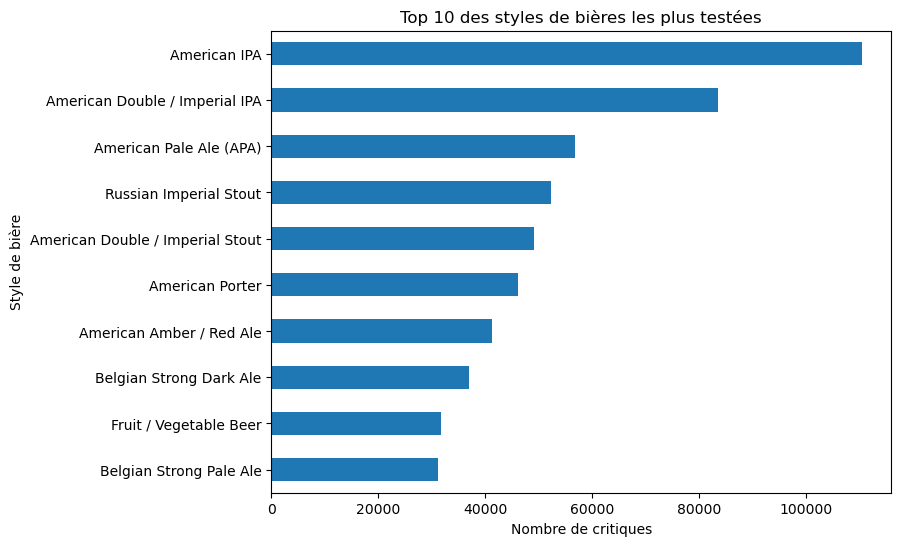

In [72]:
#style de bière les plus testées
beer_styles = df['beer_style'].value_counts().nlargest(n=10)
print(beer_styles)

plt.figure(figsize=(8,6))
beer_styles_top_n = df['beer_style'].value_counts().nlargest(n=10)
beer_styles_top_n.sort_values(inplace=True)
beer_styles_top_n.plot.barh()
plt.title('Top 10 des styles de bières les plus testées')
plt.xlabel('Nombre de critiques')
plt.ylabel('Style de bière')
plt.show()


In [73]:
review_counts = df['beer_style'].value_counts().reset_index()
review_counts.columns = ['beer_style', 'count']

fig = px.bar(review_counts, x='beer_style', y='count', title='Nombre de notes par style de bières',
             labels={'count':'Nombre de notes', 'beer_style':'Style de bière'})
fig.update_xaxes(range=[0,50])
fig.show()

*Top 10 des bières les plus testées*

beer_name
90 Minute IPA                          3206
Old Rasputin Russian Imperial Stout    3038
Sierra Nevada Celebration Ale          2929
Stone Ruination IPA                    2644
Arrogant Bastard Ale                   2633
Two Hearted Ale                        2631
Stone IPA (India Pale Ale)             2526
Sierra Nevada Pale Ale                 2526
La Fin Du Monde                        2480
Duvel                                  2448
Name: count, dtype: int64


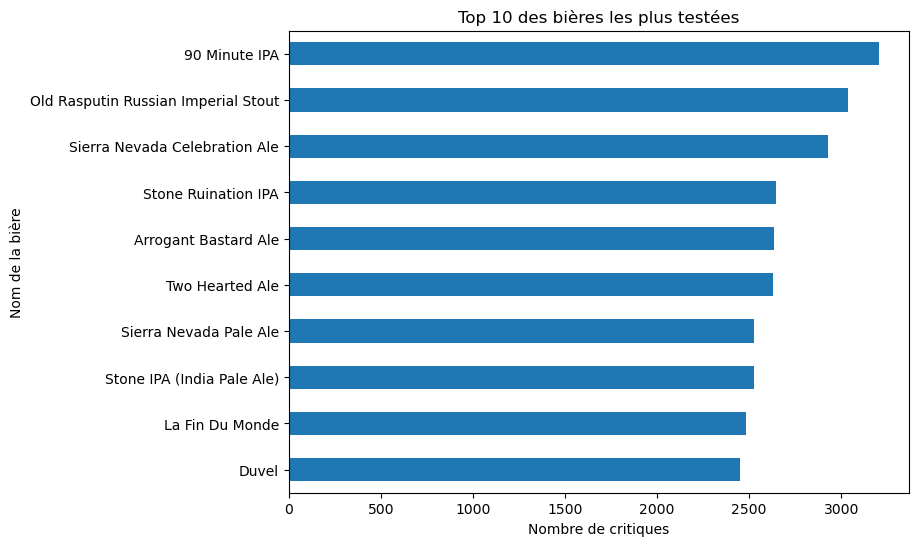

In [74]:
#nom de bière les plus testées
beer_styles = df['beer_name'].value_counts().nlargest(n=10)
print(beer_styles)

plt.figure(figsize=(8,6))
beer_styles_top_n = df['beer_name'].value_counts().nlargest(n=10)
beer_styles_top_n.sort_values(inplace=True)
beer_styles_top_n.plot.barh()
plt.title('Top 10 des bières les plus testées')
plt.xlabel('Nombre de critiques')
plt.ylabel('Nom de la bière')
plt.show()

*Top 10 des brasseries les plus testées*

brewery_name
Boston Beer Company (Samuel Adams)    38533
Dogfish Head Brewery                  33339
Stone Brewing Co.                     32525
Sierra Nevada Brewing Co.             28237
Bell's Brewery, Inc.                  24610
Rogue Ales                            22935
Founders Brewing Company              19655
Victory Brewing Company               18995
Lagunitas Brewing Company             16656
Avery Brewing Company                 15888
Name: count, dtype: int64


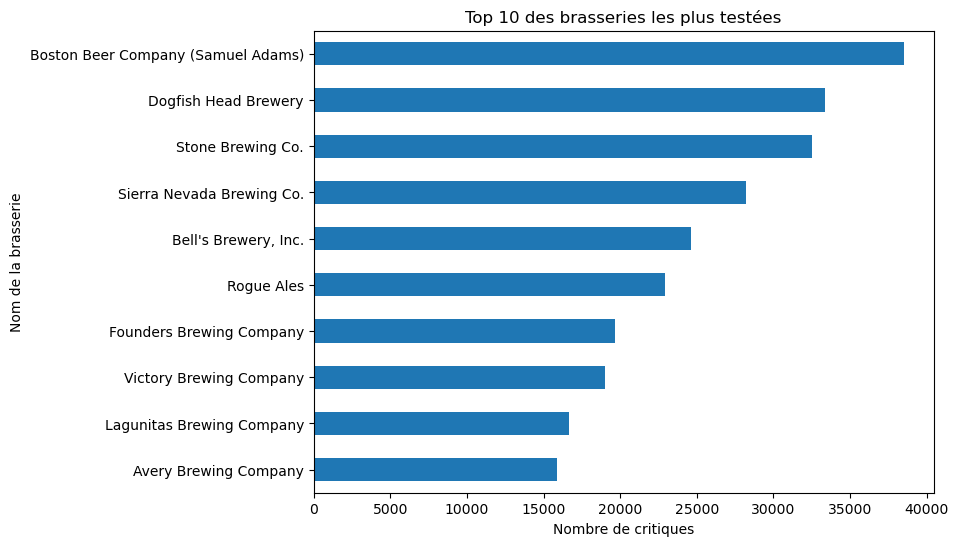

In [75]:
#brasserie testées les plus fréquentes
beer_styles = df['brewery_name'].value_counts().nlargest(n=10)
print(beer_styles)

plt.figure(figsize=(8,6))
beer_styles_top_n = df['brewery_name'].value_counts().nlargest(n=10)
beer_styles_top_n.sort_values(inplace=True)
beer_styles_top_n.plot.barh()
plt.title('Top 10 des brasseries les plus testées')
plt.xlabel('Nombre de critiques')
plt.ylabel('Nom de la brasserie')
plt.show()

*Top 10 des styles de bières les mieux notées*

In [76]:
beer_style_ratings = df.groupby('beer_style')['review_overall'].mean().sort_values(ascending=False).reset_index()
fig = px.bar(beer_style_ratings, y='beer_style', x='review_overall', orientation='h', title='Moyenne des notes globales par style de bières')
fig.update_xaxes(title_text='Moyenne des Note globale')
fig.update_yaxes(title_text='Style de bière')
fig.update_yaxes(range=[0,15])
fig.show()

In [77]:
# Style des bières les mieux notées (avec un nombre suffisant de critiques)
Best_style = df[['beer_style','review_overall']]\
    .pivot_table(index="beer_style", aggfunc=("count",'mean','median'))

Best_style.columns = Best_style.columns.to_series().str.join('_')
Best_style.reset_index()

Best_style = Best_style.query('review_overall_count >= 1000')\
  .sort_values('review_overall_mean', ascending=False)\
  .head(10)

Best_style

,review_overall_count,review_overall_mean,review_overall_median
beer_style,,,
American Wild Ale,16718,4.098786,4.0
Gueuze,5900,4.086610,4.0
Quadrupel (Quad),17837,4.072854,4.0
Lambic - Unblended,1034,4.061412,4.0
American Double / Imperial Stout,49214,4.028935,4.0
Russian Imperial Stout,52355,4.024066,4.0
Weizenbock,9181,4.010402,4.0
American Double / Imperial IPA,83632,3.997716,4.0
Flanders Red Ale,6507,3.994775,4.0


* Styles de bières le plus testé : American IPA
* Nom de la bière la plus testée : 90 Minute IPA
* Brasserie la plus testée : Boston Beer Company (Samuel Adams)

* Styles de bières les mieux notés : American Wild Ale avec une note générale de 4.09/5 et 16 718 critiques enregistrées

## Et la meilleure bière est ... ##


In [78]:
#pour considérer la meilleure bière, je dois prendre une bière qui a reçu un certain nombre de critiques pour que sa note soit valable et représentative 
# il faudrait donc que je lie le nombre de répétition/moyenne/médiane ? =pivot_table (tableau croisé dynamique)
Best_beers = df[['beer_name','review_overall']]\
    .pivot_table(index="beer_name", aggfunc=("count",'mean','median'))

#on groupe toutes les lignes comprenant des caractères ayant les mêmes valeurs, avec comme séparateur _
Best_beers.columns = Best_beers.columns.to_series().str.join('_')
#mes valeurs ne seront plus dans le même ordre (reset_index)
Best_beers.reset_index()

# Filtrer décroissant et je prends en compte que si j'ai un minimum de répétition
Best_beers = Best_beers.query('review_overall_count >= 1000')\
  .sort_values('review_overall_mean', ascending=False)\
  .head(5)

Best_beers

,review_overall_count,review_overall_mean,review_overall_median
beer_name,,,
Trappist Westvleteren 12,1272,4.617925,4.5
Pliny The Elder,2432,4.593544,4.5
Weihenstephaner Hefeweissbier,1951,4.516146,4.5
The Abyss,1366,4.447657,4.5
Sculpin India Pale Ale,1295,4.435521,4.5


*Avec 1272 critiques, la Trappist est élue MEILLEURE BIERE par +1 millions utilisateurs de Beeradvocates (période 1998-2011)*

# Recherche d'un lien entre les variables quantitatives
* Tests de corrélation
* Avis global par rapport aux autres variables

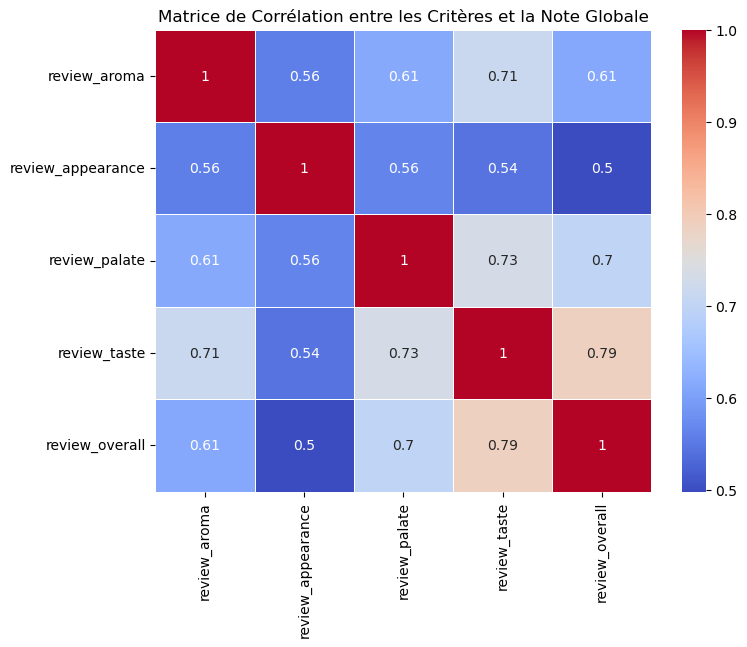

In [79]:
# Correlation matrix
correlation_matrix = df[["review_aroma", "review_appearance", "review_palate", "review_taste", "review_overall"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Matrice de Corrélation entre les Critères et la Note Globale")
plt.show()


* Le goût est le 1er facteur qui influe le plus sur la note générale
* le palais est le 2e facteur
* l'arôme le 3e facteur

C:\Users\bknju\AppData\Local\Temp\ipykernel_5368\542155755.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




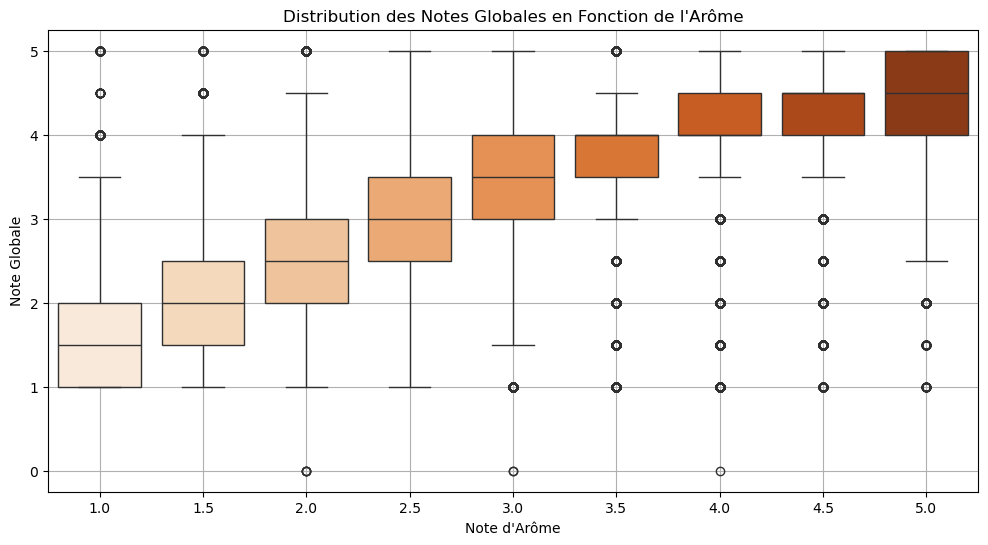

In [80]:
#dans quel mesure le goût influence t'il la note globale ?
plt.figure(figsize=(12, 6))
sns.boxplot(x="review_aroma", y="review_overall", data=df, palette="Oranges")
plt.title('Distribution des Notes Globales en Fonction de l\'Arôme')
plt.xlabel('Note d\'Arôme')
plt.ylabel('Note Globale')
plt.grid(True)
plt.show()



# Prédiction


In [81]:
#import des librairies nécessaires
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split


In [82]:
# Affichage des premières lignes pour vérification

print(df.head())
df.isnull().any()

   brewery_id             brewery_name  review_time  review_overall  \
0       10325          Vecchio Birraio   1234817823             1.5   
1       10325          Vecchio Birraio   1235915097             3.0   
2       10325          Vecchio Birraio   1235916604             3.0   
3       10325          Vecchio Birraio   1234725145             3.0   
4        1075  Caldera Brewing Company   1293735206             4.0   

   review_aroma  review_appearance review_profilename  \
0           2.0                2.5            stcules   
1           2.5                3.0            stcules   
2           2.5                3.0            stcules   
3           3.0                3.5            stcules   
4           4.5                4.0     johnmichaelsen   

                       beer_style  review_palate  review_taste  \
0                      Hefeweizen            1.5           1.5   
1              English Strong Ale            3.0           3.0   
2          Foreign / Export Stou

brewery_id            False
brewery_name          False
review_time           False
review_overall        False
review_aroma          False
review_appearance     False
review_profilename    False
beer_style            False
review_palate         False
review_taste          False
beer_name             False
beer_abv              False
beer_beerid           False
dtype: bool

*Modèle 1 - régression linéaire*

In [83]:
features_list = ["review_palate", "review_time", "beer_abv","review_taste","review_aroma","review_appearance","beer_beerid"]  
X = df.loc[:, features_list]
y = df.loc[:,"review_overall"]  #variable cible

print("Séparation des features et de la cible... Terminé.")

Séparation des features et de la cible... Terminé.


In [84]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, )

print("Division en train/test... Terminé.")
X_train.head()

Division en train/test... Terminé.


,review_palate,review_time,beer_abv,review_taste,review_aroma,review_appearance,beer_beerid
1079522,3.5,1325491140,6.00,4.0,4.0,4.5,62050
1538905,4.0,1201708838,5.20,4.5,4.0,4.0,29824
106233,2.0,1213381678,7.50,2.5,2.5,4.0,6841
949489,4.0,1135209751,6.70,4.0,4.0,3.5,25875
455918,4.0,1300133606,5.75,4.5,4.0,4.0,2810


In [85]:
# Vérifier et gérer les valeurs manquantes

print("Imputing missing values...")
print(X_train)
print()
imputer = SimpleImputer(strategy="mean") 
X_train = X_train.copy()

# Apply imputer only to numeric columns
numeric_columns = [0, 1, 2, 3, 4, 5, 6] 
X_train_numeric = X_train.iloc[:, numeric_columns]
X_train = imputer.fit_transform(X_train_numeric)
X_test = imputer.fit_transform(X_test)
print("...Done!")
print(X_train)

print()
print(f"Nombre de valeurs NaN dans X_train :\n{pd.DataFrame(X_train).isnull().sum().sum()}")



Imputing missing values...
         review_palate  review_time  beer_abv  review_taste  review_aroma  \
1079522            3.5   1325491140      6.00           4.0           4.0   
1538905            4.0   1201708838      5.20           4.5           4.0   
106233             2.0   1213381678      7.50           2.5           2.5   
949489             4.0   1135209751      6.70           4.0           4.0   
455918             4.0   1300133606      5.75           4.5           4.0   
...                ...          ...       ...           ...           ...   
159190             4.0   1318909462     11.20           4.5           4.5   
1018108            4.0   1324101876      6.80           4.5           4.5   
122925             4.0   1322428611      5.40           3.5           3.5   
1573876            4.0   1303415687      8.00           4.0           3.5   
319347             3.5   1287885048      5.50           3.5           3.5   

         review_appearance  beer_beerid  
107952

In [86]:
# Définition des transformations pour les colonnes numériques et catégoriques
numeric_features = [0, 1, 2, 3, 4, 5, 6]   
numeric_transformer = StandardScaler()

categorical_features =[0]  
categorical_transformer = OneHotEncoder(drop="first", handle_unknown='ignore')


featureencoder = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
X_train = featureencoder.fit_transform(X_train)
print(X_train[:5])

LabelEncoder = LabelEncoder()
y_train = LabelEncoder.fit_transform(y_train)
print(y_train[:5])

print("Prétraitement des données... Terminé.")


[[-0.37108078  1.31928517 -0.44926137  0.27089667  0.36663895  1.05812148
   1.86276263  0.          0.          0.          0.          1.
   0.          0.          0.        ]
 [ 0.36402821 -0.31548034 -0.793134    0.95641084  0.36663895  0.24505654
   0.38440922  0.          0.          0.          0.          0.
   1.          0.          0.        ]
 [-2.57640775 -0.16131972  0.1954998  -1.78564584 -1.78864893  0.24505654
  -0.66992568  0.          1.          0.          0.          0.
   0.          0.          0.        ]
 [ 0.36402821 -1.19371908 -0.14837283  0.27089667  0.36663895 -0.5680084
   0.2032506   0.          0.          0.          0.          0.
   1.          0.          0.        ]
 [ 0.36402821  0.98439382 -0.55672157  0.95641084  0.36663895  0.24505654
  -0.85484601  0.          0.          0.          0.          0.
   1.          0.          0.        ]]
[7 8 5 7 8]
Prétraitement des données... Terminé.


In [87]:
print("train model ...")

regressor = LinearRegression()
regressor.fit(X_train, y_train)

print("..Fait")

train model ...
..Fait


In [88]:
print("Predictions sur le set Train... ")

y_train_pred = regressor.predict(X_train)


print("..fait.")

print(y_train_pred[:5])

print()

Predictions sur le set Train... 
..fait.
[6.92143422 7.75507197 3.9670206  7.03335157 7.74313325]



In [89]:
X_test = X_test.copy()

# Select only the numeric columns for transformation
X_test = X_test[:, numeric_columns]

# Standardizing numeric features
print("Standardizing numerical features...")


X_test = featureencoder.transform(X_test)

print("...Done.")
print(X_test[:5]) # print first 5 rows (not using iloc since now X_test became a numpy array)
print()

y_test = LabelEncoder.transform(y_test)
print(y_test)


Standardizing numerical features...
...Done.
[[-1.10618977  0.14589281 -0.66418177 -1.10013167 -1.07021963 -1.38107334
   0.99440318  0.          0.          0.          1.          0.
   0.          0.          0.        ]
 [-1.10618977 -2.37985363 -0.87910216 -1.10013167 -1.07021963 -1.38107334
  -0.87328759  0.          0.          0.          1.          0.
   0.          0.          0.        ]
 [-0.37108078 -0.31269616 -0.44926137 -0.4146175  -0.35179034 -0.5680084
  -0.33921601  0.          0.          0.          0.          1.
   0.          0.          0.        ]
 [ 0.36402821  1.28675862  0.1954998   0.27089667  0.36663895  0.24505654
   0.767737    0.          0.          0.          0.          0.
   1.          0.          0.        ]
 [-1.10618977 -2.12016022 -0.75014992 -0.4146175   0.36663895  0.24505654
  -0.97907431  0.          0.          0.          1.          0.
   0.          0.          0.        ]]

[5 5 7 ... 6 7 6]


In [90]:
print("R2 score sur le set  training  : ", regressor.score(X_train, y_train))
print("R2 score sur le set  test :", regressor.score(X_test, y_test))

R2 score sur le set  training  :  0.6711033375980716
R2 score sur le set  test : 0.6698157847336099


In [91]:
print("Les coefficients sont :",regressor.coef_)
print("La constante :", regressor.intercept_)

Les coefficients sont : [-6.33599156e+07  8.99074972e-03 -1.86110521e-01  8.02360527e-01
  1.05374742e-01  5.75308055e-02 -1.64399338e-02  4.65764440e+07
  9.31528880e+07  1.39729332e+08  1.86305776e+08  2.32882220e+08
  2.79458664e+08  3.26035108e+08  3.72611552e+08]
La constante : -256393860.18718743


In [92]:
# Access transformers from feature_encoder
print("All transformers are: ", featureencoder.transformers_)

# Access one specific transformer
print("One Hot Encoder transformer is: ", featureencoder.transformers_[1][1])

All transformers are:  [('num', StandardScaler(), [0, 1, 2, 3, 4, 5, 6]), ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), [0])]
One Hot Encoder transformer is:  OneHotEncoder(drop='first', handle_unknown='ignore')


In [93]:
# Print categories
categorical_column_names = featureencoder.transformers_[1][1].categories_
print("Categorical columns are: ", categorical_column_names)


Categorical columns are:  [array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])]


In [94]:
numerical_column_names = X.iloc[:, numeric_features].columns # using the .columns attribute gives us the name of the column 
print("numerical columns are: ", numerical_column_names)

numerical columns are:  Index(['review_palate', 'review_time', 'beer_abv', 'review_taste',
       'review_aroma', 'review_appearance', 'beer_beerid'],
      dtype='object')


In [95]:
all_column_names = np.append(categorical_column_names, numerical_column_names)
all_column_names

array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 'review_palate',
       'review_time', 'beer_abv', 'review_taste', 'review_aroma',
       'review_appearance', 'beer_beerid'], dtype=object)

In [96]:
# Get the feature names after one-hot encoding
one_hot_encoded_feature_names = featureencoder.transformers_[1][1].get_feature_names_out()
all_feature_names = np.append(numerical_column_names, one_hot_encoded_feature_names)

# Feature importance 
feature_importance = pd.DataFrame({
    "feature_names": all_feature_names,
    "coefficients": regressor.coef_
})

feature_importance

,feature_names,coefficients
0,review_palate,-6.335992e+07
1,review_time,8.990750e-03
2,beer_abv,-1.861105e-01
3,review_taste,8.023605e-01
4,review_aroma,1.053747e-01
5,review_appearance,5.753081e-02
6,beer_beerid,-1.643993e-02
7,x0_1.5,4.657644e+07
8,x0_2.0,9.315289e+07
9,x0_2.5,1.397293e+08


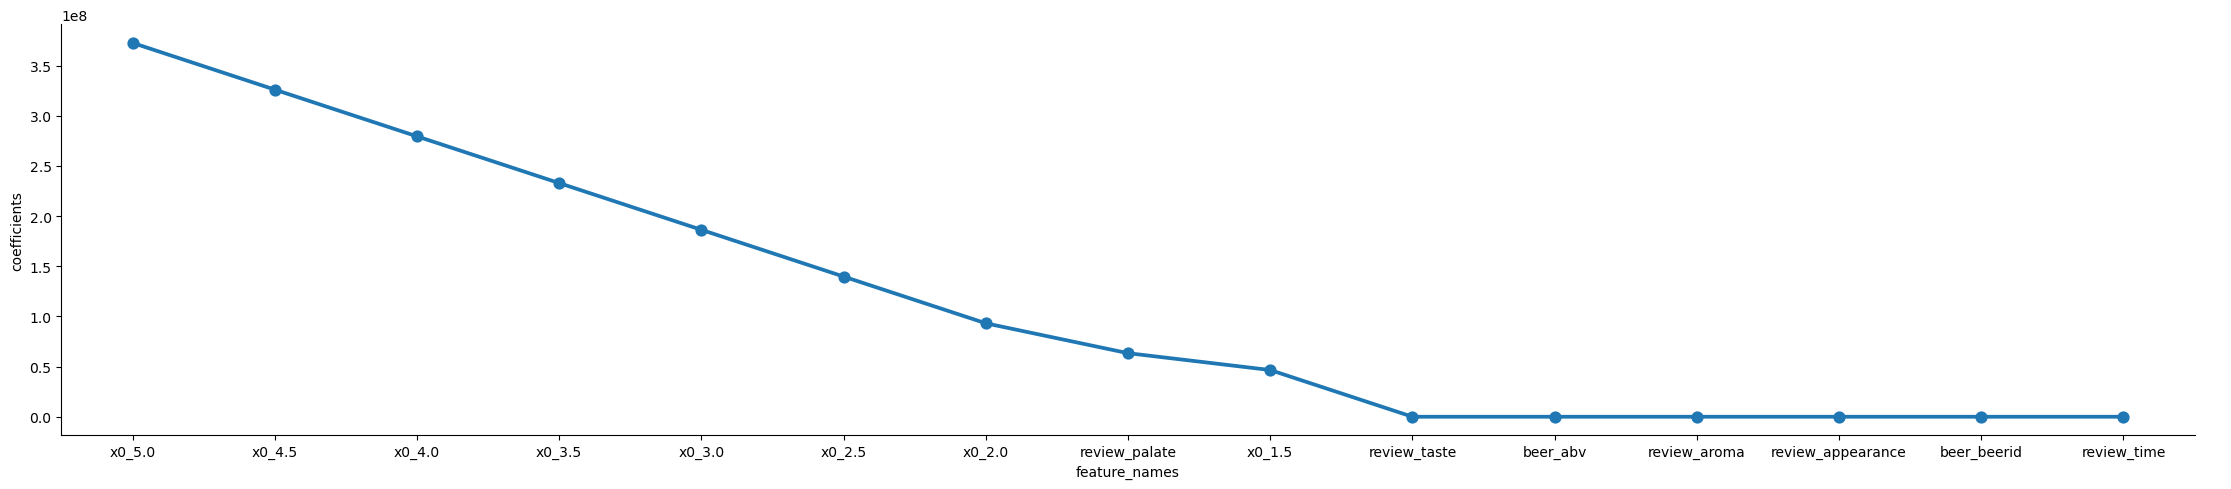

In [97]:
# Set coefficient to absolute values to rank features
feature_importance["coefficients"] = feature_importance["coefficients"].abs()

# Visualize ranked features using seaborn
sns.catplot(x="feature_names", 
            y="coefficients", 
            data=feature_importance.sort_values(by="coefficients", ascending=False), 
            kind="point",
            aspect=40/9) # Resize graph

*Modèle 2 - ridge lasso*

In [98]:
# Sélection des variables explicatives et de la cible
features_list = ["review_palate", "review_time", "beer_abv", "review_taste", "review_aroma", "review_appearance", "beer_beerid", "brewery_name", "beer_style"]
X = df.loc[:, features_list]
y = df.loc[:, "review_overall"]


In [99]:
# Division en jeu d'entraînement et jeu de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [100]:
# Traitement des valeurs manquantes
imputer = SimpleImputer(strategy="mean")
X_train.iloc[:, :7] = imputer.fit_transform(X_train.iloc[:, :7])
X_test.iloc[:, :7] = imputer.transform(X_test.iloc[:, :7])


In [101]:
# Transformation des données (mise à l'échelle et encodage)
numeric_features = list(range(7))
numeric_transformer = StandardScaler()

# Catégories à encoder
categorical_features = [7, 8]

# Column transformer pour gérer les transformations
featureencoder = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown='ignore'), categorical_features)
    ]
)

# Application de la transformation sur les données d'entraînement
X_train = featureencoder.fit_transform(X_train)
X_test = featureencoder.transform(X_test)


c:\Users\bknju\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



In [102]:
# Entraînement du modèle Ridge
ridge_regressor = Ridge(alpha=1.0)
ridge_regressor.fit(X_train, y_train)

# Prédictions sur le jeu d'entraînement et de test
y_train_pred_ridge = ridge_regressor.predict(X_train)
y_test_pred_ridge = ridge_regressor.predict(X_test)

In [103]:
# Évaluation du modèle Ridge
print(f"R2 score (Ridge) sur le set d'entraînement : {ridge_regressor.score(X_train, y_train):.4f}")
print(f"R2 score (Ridge) sur le set de test : {ridge_regressor.score(X_test, y_test):.4f}")

print("Coefficients (Ridge) :", ridge_regressor.coef_)
print("Constante (Ridge) :", ridge_regressor.intercept_)

R2 score (Ridge) sur le set d'entraînement : 0.6804
R2 score (Ridge) sur le set de test : 0.6769
Coefficients (Ridge) : [ 0.18333098  0.00495442 -0.07072185 ... -0.08683817 -0.07676549
  0.01944212]
Constante (Ridge) : 3.8072243190765795


In [104]:
print("Importance des caractéristiques :")
print(feature_importance.sort_values(by="coefficients", key=np.abs, ascending=False))


Importance des caractéristiques :
        feature_names  coefficients
14             x0_5.0  3.726116e+08
13             x0_4.5  3.260351e+08
12             x0_4.0  2.794587e+08
11             x0_3.5  2.328822e+08
10             x0_3.0  1.863058e+08
9              x0_2.5  1.397293e+08
8              x0_2.0  9.315289e+07
0       review_palate  6.335992e+07
7              x0_1.5  4.657644e+07
3        review_taste  8.023605e-01
2            beer_abv  1.861105e-01
4        review_aroma  1.053747e-01
5   review_appearance  5.753081e-02
6         beer_beerid  1.643993e-02
1         review_time  8.990750e-03


*Modèle 3 - Classification*

In [105]:
# Création de la variable cible binaire : 1 = Bonne bière (note >= 4), 0 = Mauvaise bière (note < 4)
df['target'] = (df['review_overall'] >= 4).astype(int)

In [106]:
# Sélection des variables explicatives et de la cible
features_list = ["review_palate", "review_time", "beer_abv", "review_taste", "review_aroma", "review_appearance", "beer_beerid", "beer_style", "brewery_name"]
X = df.loc[:, features_list]
y = df.loc[:, "target"]


In [107]:
# Division en jeu d'entraînement et jeu de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [108]:
# Traitement des valeurs manquantes
imputer = SimpleImputer(strategy="mean")
X_train_numeric = imputer.fit_transform(X_train.iloc[:, :7])
X_test_numeric = imputer.transform(X_test.iloc[:, :7])


In [109]:
# Transformation des données (mise à l'échelle et encodage)
numeric_features = list(range(7))
numeric_transformer = StandardScaler()

# Catégories à encoder
categorical_features = [7, 8]

# Column transformer pour gérer les transformations
featureencoder = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown='ignore'), categorical_features)
    ]
)

# Application de la transformation sur les données d'entraînement
X_train_combined = np.hstack((X_train_numeric, X_train.iloc[:, 7:].values))
X_test_combined = np.hstack((X_test_numeric, X_test.iloc[:, 7:].values))

X_train = featureencoder.fit_transform(X_train_combined)
X_test = featureencoder.transform(X_test_combined)


c:\Users\bknju\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros



In [110]:
# Entraînement du modèle de classification (Logistic Regression)
logistic_model = LogisticRegression(max_iter=1000, random_state=0)
logistic_model.fit(X_train, y_train)

# Prédictions sur les ensembles d'entraînement et de test
y_train_pred = logistic_model.predict(X_train)
y_test_pred = logistic_model.predict(X_test)


In [111]:
# Prédictions sur les ensembles d'entraînement et de test
y_train_pred = logistic_model.predict(X_train)
y_test_pred = logistic_model.predict(X_test)

# Évaluation du modèle
print("Accuracy sur le jeu d'entraînement :", accuracy_score(y_train, y_train_pred))
print("Accuracy sur le jeu de test :", accuracy_score(y_test, y_test_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_test_pred))
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_test_pred))


Accuracy sur le jeu d'entraînement : 0.8382536486746143
Accuracy sur le jeu de test : 0.8372948642118876

Rapport de classification :
               precision    recall  f1-score   support

           0       0.82      0.72      0.76    109686
           1       0.85      0.91      0.88    189567

    accuracy                           0.84    299253
   macro avg       0.83      0.81      0.82    299253
weighted avg       0.84      0.84      0.83    299253


Matrice de confusion :
 [[ 78636  31050]
 [ 17640 171927]]


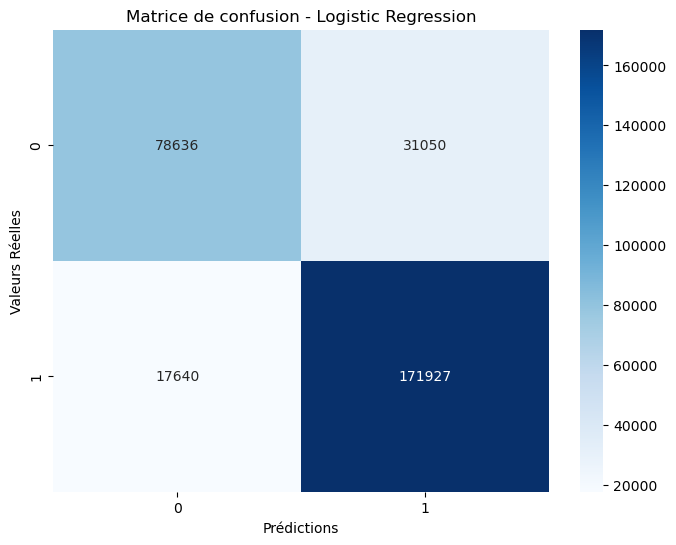

In [112]:
# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Logistic Regression")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
plt.show()


In [113]:
# Entraînement du modèle de classification (Random Forest)
rf_model = RandomForestClassifier(n_estimators=30, max_depth=15, random_state=0, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prédictions sur les ensembles d'entraînement et de test
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [114]:
# Évaluation du modèle
print("Accuracy sur le jeu d'entraînement :", accuracy_score(y_train, y_train_pred))
print("Accuracy sur le jeu de test :", accuracy_score(y_test, y_test_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_test_pred))
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_test_pred))

Accuracy sur le jeu d'entraînement : 0.7674054519176949
Accuracy sur le jeu de test : 0.7653858106685647

Rapport de classification :
               precision    recall  f1-score   support

           0       0.87      0.42      0.57    109686
           1       0.74      0.96      0.84    189567

    accuracy                           0.77    299253
   macro avg       0.81      0.69      0.70    299253
weighted avg       0.79      0.77      0.74    299253


Matrice de confusion :
 [[ 46562  63124]
 [  7085 182482]]


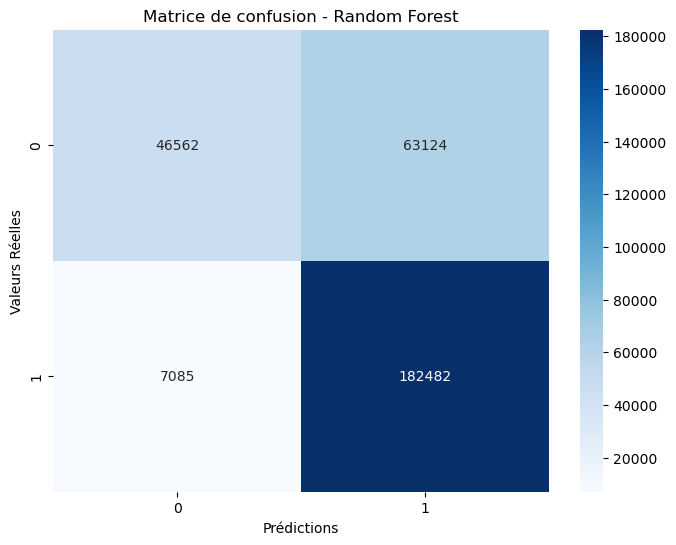

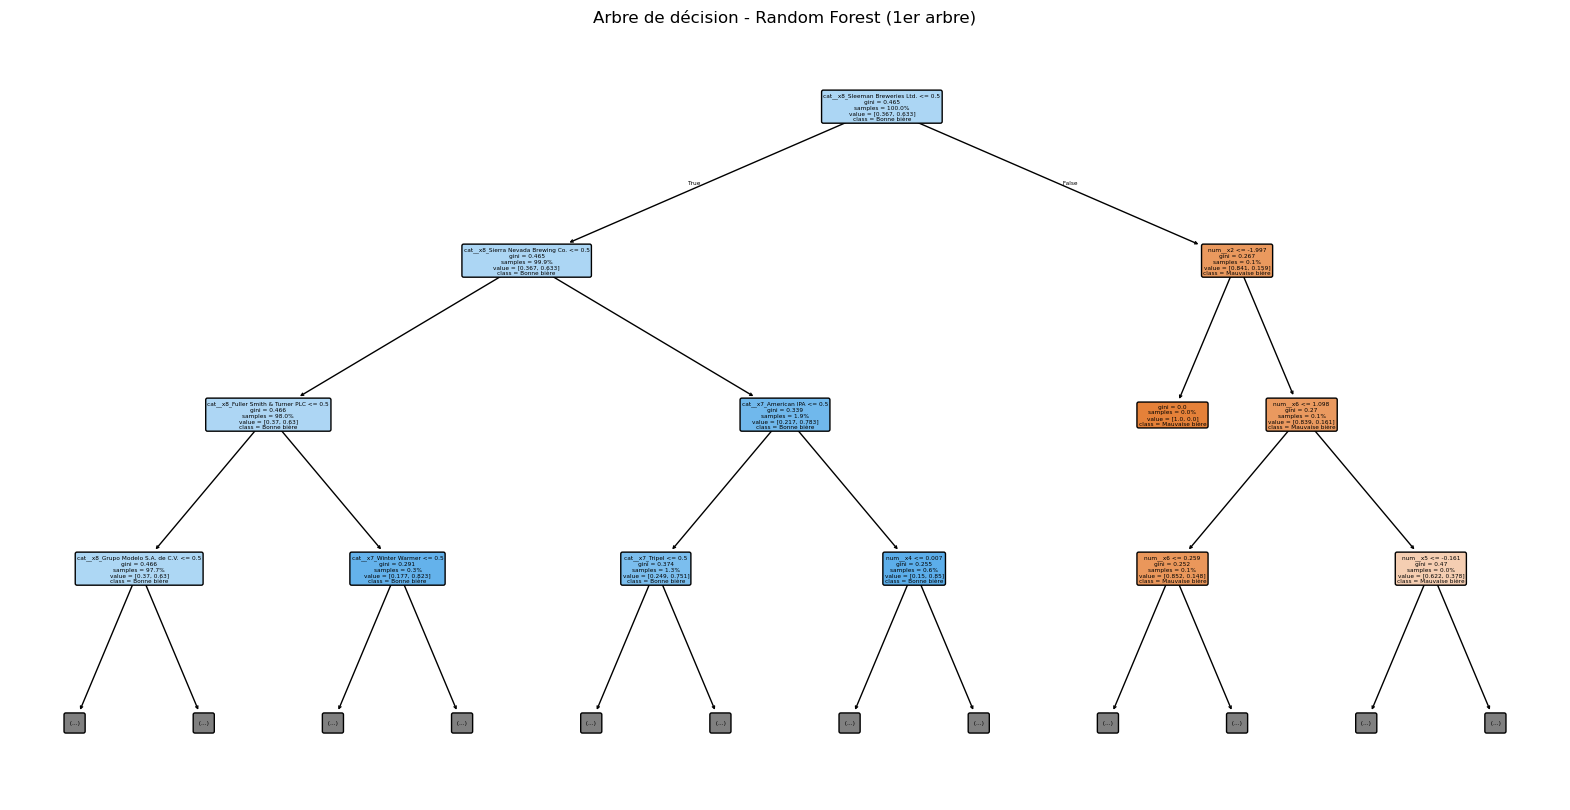

In [115]:
# Matrice de confusion
plt.figure(figsize=(8, 6))
y_test_pred = rf_model.predict(X_test)  # Assurez-vous que vous avez défini y_test_pred
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
plt.show()

# Importance des features pour Random Forest
feature_importances = rf_model.feature_importances_

# Assurez-vous que le feature encoder est bien défini et que les données sont traitées avant l'usage
# Utilisez get_feature_names_out() si vous avez un encodeur OneHotEncoder
# Si vous avez utilisé un autre encodage, vous devrez ajuster cette partie en fonction de l'encodeur utilisé.
feature_names = featureencoder.get_feature_names_out()  # Assurez-vous que featureencoder est correctement défini

# Création d'un DataFrame pour visualiser les importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Tri des features par importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Visualisation des importances des features
'''plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Importance des features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()'''

# Visualisation d'un arbre de décision dans Random Forest
# Sélection d'un arbre dans la forêt (par exemple, le premier arbre)
estimator = rf_model.estimators_[0]

# Tracer l'arbre de décision
plt.figure(figsize=(20, 10))
plot_tree(estimator, 
          feature_names=feature_names,  # Utilisez les noms des features après transformation
          class_names=["Mauvaise bière", "Bonne bière"],  # Noms des classes
          filled=True, 
          rounded=True, 
          proportion=True, 
          max_depth=3)  # Limitez la profondeur pour une meilleure lisibilité

plt.title("Arbre de décision - Random Forest (1er arbre)")
plt.show()